In [6]:
import copernicusmarine
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm 
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
# copernicusmarine.open_dataset?

In [7]:
def monthly_mean(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

def seasonality(data):

    ss = data['time'].dt.season
    ss_means = data.groupby(ss).mean('time')
    return ss_means

In [3]:
# from dask.distributed import Client
# client = Client(n_workers=2, threads_per_worker=3, memory_limit=15e9)
# client

In [4]:
# !echo dask dashboard xd
# !echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

In [5]:
# Set parameters
data_request = {
   "dataset_id_plume" : "cmems_mod_glo_phy_my_0.083deg_P1D-m",
   "dataset_version": "202311",
   "longitude" : [-75, -35], 
   "latitude" : [-10, 30],
   "time" : ["1993-01-01", "2021-06-30"],
   "variables" : ["vo","uo"]
}

# Load xarray dataset
ds = copernicusmarine.open_dataset(
    dataset_id = data_request["dataset_id_plume"],
    minimum_longitude = data_request["longitude"][0],
    maximum_longitude = data_request["longitude"][1],
    minimum_latitude = data_request["latitude"][0],
    maximum_latitude = data_request["latitude"][1],
    start_datetime = data_request["time"][0],
    end_datetime = data_request["time"][1],
    minimum_depth=0.49402499198913574,
    maximum_depth=0.49402499198913574,
    variables = data_request["variables"],
    username = 'dbarreto',
    password = 'DoNuT_120197',
    chunk_size_limit = -1
)

# Print loaded dataset information
ds

INFO - 2025-08-07T13:32:00Z - Selected dataset version: "202311"
INFO - 2025-08-07T13:32:00Z - Selected dataset part: "default"


<xarray.Dataset> Size: 39GB
Dimensions:    (depth: 1, latitude: 481, longitude: 481, time: 10408)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 2kB -10.0 -9.917 -9.833 ... 29.83 29.92 30.0
  * longitude  (longitude) float32 2kB -75.0 -74.92 -74.83 ... -35.08 -35.0
  * time       (time) datetime64[ns] 83kB 1993-01-01 1993-01-02 ... 2021-06-30
Data variables:
    vo         (time, depth, latitude, longitude) float64 19GB dask.array<chunksize=(2081, 1, 481, 64), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float64 19GB dask.array<chunksize=(2081, 1, 481, 64), meta=np.ndarray>
Attributes:
    title:        daily mean fields from Global Ocean Physics Analysis and Fo...
    references:   http://www.mercator-ocean.fr
    comment:      CMEMS product
    source:       MERCATOR GLORYS12V1
    history:      2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
    institution:  MERCATOR OCEAN
    Conventions:  CF-1.4

In [6]:
ds = ds.chunk({"time": 365, "latitude": 133, "longitude": 266})
ds

<xarray.Dataset> Size: 39GB
Dimensions:    (depth: 1, latitude: 481, longitude: 481, time: 10408)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 2kB -10.0 -9.917 -9.833 ... 29.83 29.92 30.0
  * longitude  (longitude) float32 2kB -75.0 -74.92 -74.83 ... -35.08 -35.0
  * time       (time) datetime64[ns] 83kB 1993-01-01 1993-01-02 ... 2021-06-30
Data variables:
    vo         (time, depth, latitude, longitude) float64 19GB dask.array<chunksize=(365, 1, 133, 266), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float64 19GB dask.array<chunksize=(365, 1, 133, 266), meta=np.ndarray>
Attributes:
    title:        daily mean fields from Global Ocean Physics Analysis and Fo...
    references:   http://www.mercator-ocean.fr
    comment:      CMEMS product
    source:       MERCATOR GLORYS12V1
    history:      2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
    institution:  MERCATOR OCEAN
    Conventions:  CF-1.4

In [7]:
UV = (ds.vo.isel(depth=0)**2 + ds.uo.isel(depth=0)**2)**0.5
UV

<xarray.DataArray (time: 10408, latitude: 481, longitude: 481)> Size: 19GB
dask.array<pow, shape=(10408, 481, 481), dtype=float64, chunksize=(365, 133, 266), chunktype=numpy.ndarray>
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 2kB -10.0 -9.917 -9.833 ... 29.83 29.92 30.0
  * longitude  (longitude) float32 2kB -75.0 -74.92 -74.83 ... -35.08 -35.0
  * time       (time) datetime64[ns] 83kB 1993-01-01 1993-01-02 ... 2021-06-30

In [8]:
uv_season = seasonality(UV)
uv_season = uv_season.compute()
uv_season

<xarray.DataArray (season: 4, latitude: 481, longitude: 481)> Size: 7MB
array([[[       nan,        nan,        nan, ..., 0.17950009,
         0.1793445 , 0.17892525],
        [       nan,        nan,        nan, ..., 0.18612013,
         0.18487417, 0.18630745],
        [       nan,        nan,        nan, ..., 0.19614455,
         0.19525217, 0.19188557],
        ...,
        [0.24575088, 0.24475506, 0.24416379, ..., 0.1155845 ,
         0.11709641, 0.11639217],
        [0.24150357, 0.2414047 , 0.24125931, ..., 0.11747043,
         0.11892478, 0.11805135],
        [0.23924629, 0.23847883, 0.23781624, ..., 0.11878278,
         0.12053265, 0.12035593]],

       [[       nan,        nan,        nan, ..., 0.36441915,
         0.32948474, 0.28584034],
        [       nan,        nan,        nan, ..., 0.41517692,
         0.37639709, 0.32202649],
        [       nan,        nan,        nan, ..., 0.44909057,
         0.43180319, 0.39389998],
...
        [0.28019343, 0.27754939, 0.27580617, ..., 0.10780133,
         0.1086551 , 0.10900509],
        [0.27883626, 0.27616015, 0.27644921, ..., 0.10890808,
         0.1089733 , 0.10843342],
        [0.28124006, 0.27915135, 0.27804848, ..., 0.11136028,
         0.1109125 , 0.10968895]],

       [[       nan,        nan,        nan, ..., 0.2162223 ,
         0.20667301, 0.19403381],
        [       nan,        nan,        nan, ..., 0.23118226,
         0.21996442, 0.20593436],
        [       nan,        nan,        nan, ..., 0.24645129,
         0.2395704 , 0.22705743],
        ...,
        [0.28111783, 0.27500996, 0.26917309, ..., 0.10121677,
         0.10106789, 0.10048436],
        [0.28010503, 0.27446541, 0.26983457, ..., 0.1017013 ,
         0.1013224 , 0.10101481],
        [0.28145335, 0.27676739, 0.27273579, ..., 0.10236917,
         0.10167296, 0.10124553]]], shape=(4, 481, 481))
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 2kB -10.0 -9.917 -9.833 ... 29.83 29.92 30.0
  * longitude  (longitude) float32 2kB -75.0 -74.92 -74.83 ... -35.08 -35.0
  * season     (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

In [9]:
vo_s = seasonality(ds.vo.isel(depth=0)).compute()
uo_s = seasonality(ds.uo.isel(depth=0)).compute()

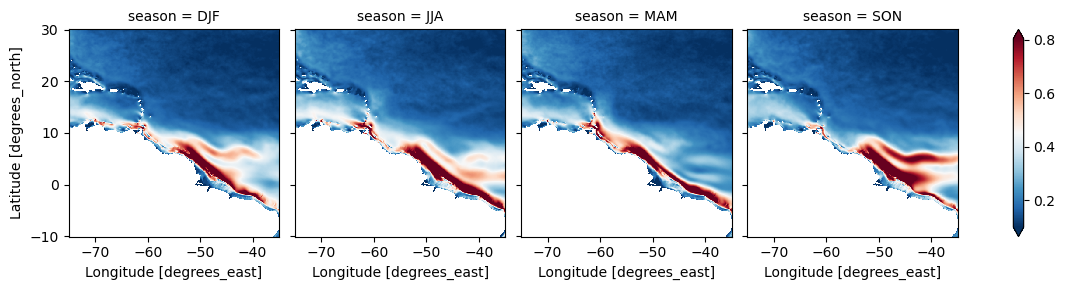

In [10]:
uv_season.plot(
    x="longitude", y="latitude", col="season", col_wrap=4, robust=True, cmap= 'RdBu_r', figsize=(12, 3))

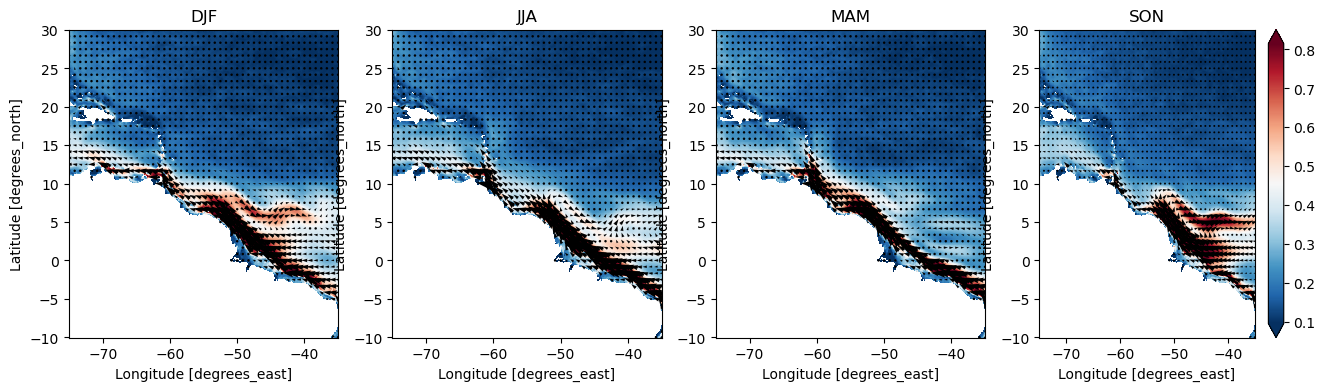

In [11]:
# Suponiendo que u_season y v_season tienen dims: (season, latitude, longitude)
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))

for i, season in enumerate(uv_season.season.values):
    ax = axes[i]
    # Scalar field
    uv_season.sel(season=season).plot(
        ax=ax,
        x="longitude", y="latitude",
        cmap="RdBu_r",
        robust=True,
        add_colorbar=(i == 3),
    )
    # Arrows
    u = uo_s.sel(season=season)
    v = vo_s.sel(season=season)
    ax.quiver(
        u.longitude[::10],
        u.latitude[::10],
        u.values[::10, ::10],
        v.values[::10, ::10],
        scale=0.4,             # ← esto desactiva la normalización y deja tamaño real
        scale_units="xy",       # ← las longitudes se interpretan en la escala del eje
        width=0.01,             # ← grosor visible
        color="k",
        pivot="middle"
    )   
    ax.set_title(str(season))


### Montly mean

In [15]:
UV_mo = monthly_mean(UV)
UV_mo = UV_mo.compute()
UV_mo

<xarray.DataArray (month: 12, latitude: 481, longitude: 481)> Size: 22MB
array([[[       nan,        nan,        nan, ..., 0.16416704,
         0.17135248, 0.17406716],
        [       nan,        nan,        nan, ..., 0.16395133,
         0.17168666, 0.17869133],
        [       nan,        nan,        nan, ..., 0.16901341,
         0.17406252, 0.17790293],
        ...,
        [0.24691458, 0.24891937, 0.25321794, ..., 0.11087934,
         0.11367589, 0.11186674],
        [0.24113706, 0.24475803, 0.25009677, ..., 0.11413312,
         0.11642259, 0.11427492],
        [0.23468919, 0.23679167, 0.24201625, ..., 0.11799847,
         0.12027528, 0.1184214 ]],

       [[       nan,        nan,        nan, ..., 0.19240092,
         0.19497812, 0.19331267],
        [       nan,        nan,        nan, ..., 0.19603737,
         0.1990785 , 0.20263578],
        [       nan,        nan,        nan, ..., 0.19804429,
         0.20769975, 0.20829697],
...
        [0.26365986, 0.25867969, 0.2544789 , ..., 0.10154722,
         0.10415306, 0.10626103],
        [0.26843438, 0.26392168, 0.25951911, ..., 0.10055653,
         0.10199741, 0.10378759],
        [0.27295362, 0.26921825, 0.26532431, ..., 0.09954405,
         0.10012155, 0.10137478]],

       [[       nan,        nan,        nan, ..., 0.18320819,
         0.17287087, 0.1703816 ],
        [       nan,        nan,        nan, ..., 0.19972328,
         0.18513019, 0.178789  ],
        [       nan,        nan,        nan, ..., 0.22245217,
         0.20545369, 0.19088264],
        ...,
        [0.23969314, 0.23450812, 0.2312536 , ..., 0.12422928,
         0.12592545, 0.12498247],
        [0.23168911, 0.22689494, 0.22320457, ..., 0.12492437,
         0.12674132, 0.12602386],
        [0.22704189, 0.22199398, 0.21793039, ..., 0.12280953,
         0.12444835, 0.12418321]]], shape=(12, 481, 481))
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 2kB -10.0 -9.917 -9.833 ... 29.83 29.92 30.0
  * longitude  (longitude) float32 2kB -75.0 -74.92 -74.83 ... -35.08 -35.0
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

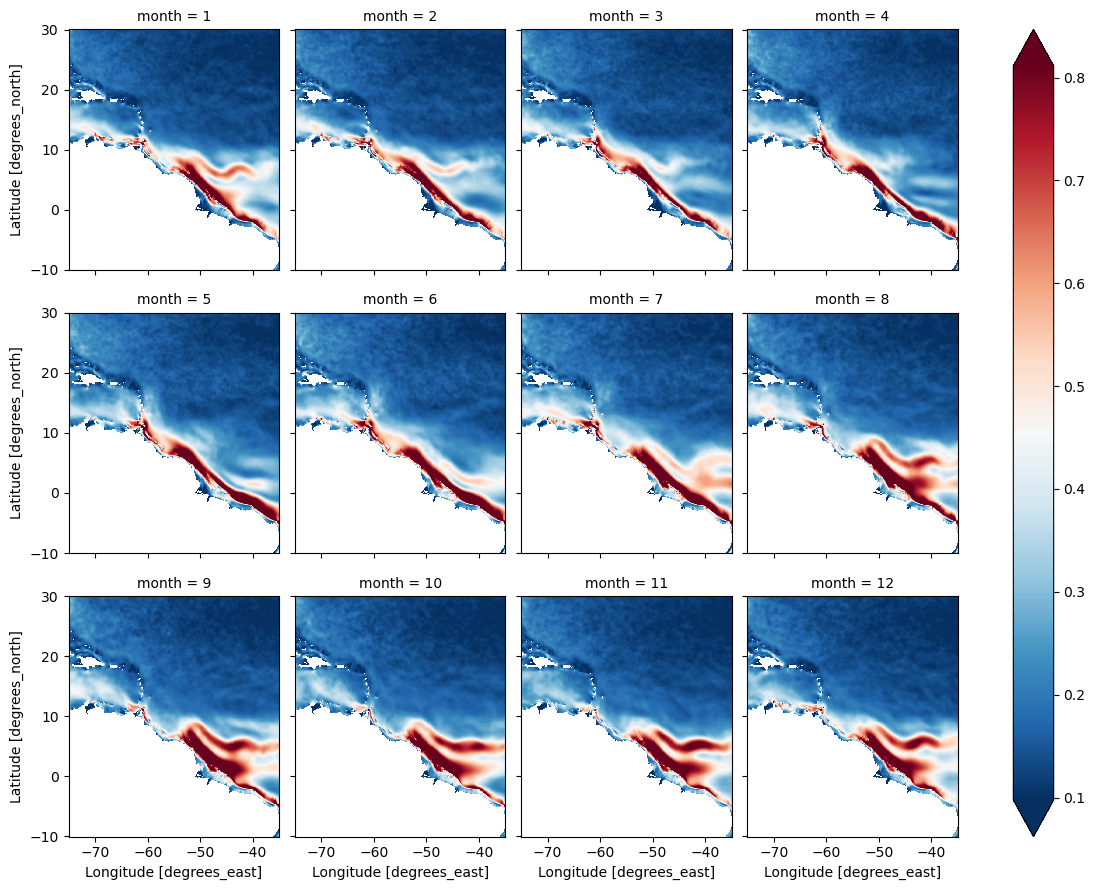

In [17]:
UV_mo.plot(
    x="longitude", y="latitude", col="month", col_wrap=4, robust=True, cmap= 'RdBu_r', figsize=(12, 9))

In [18]:
U_mo = monthly_mean(ds.uo.isel(depth=0))
U_mo = U_mo.compute()

V_mo = monthly_mean(ds.vo.isel(depth=0))
V_mo = V_mo.compute()

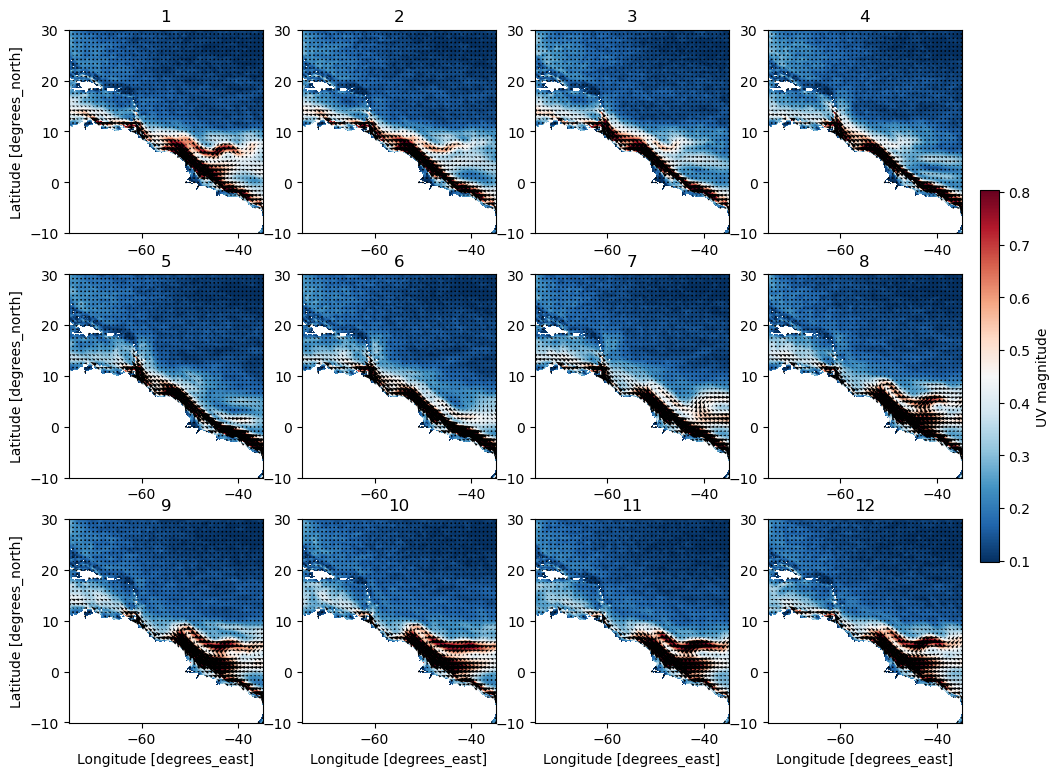

In [25]:
# Suponiendo que u_season y v_season tienen dims: (season, latitude, longitude)
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 9))

for i, month in enumerate(UV_mo.month.values):
    ax = axes[i // 4, i % 4]
    # Scalar field
    cc = UV_mo.sel(month=month).plot(
        ax=ax,
        x="longitude", y="latitude",
        cmap="RdBu_r",
        robust=True,
        add_colorbar=False,
    )
    # Arrows
    u = U_mo.sel(month=month)
    v = V_mo.sel(month=month)
    ax.quiver(
        u.longitude[::10],
        u.latitude[::10],
        u.values[::10, ::10],
        v.values[::10, ::10],
        scale=0.4,             # ← esto desactiva la normalización y deja tamaño real
        scale_units="xy",       # ← las longitudes se interpretan en la escala del eje
        width=0.01,             # ← grosor visible
        color="k",
        pivot="middle"
    )   
    ax.set_title(str(month))

    # Clean axis labels
    if i % 4 != 0:
        ax.set_ylabel("")
    if i < 8:
        ax.set_xlabel("")

# Agregar la colorbar afuera
cbar = fig.colorbar(cc, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label("UV magnitude")

plt.show()